In [ ]:
from CART import Controller, Neo4jConnection, SubnetPivotAnalyzer

connection = Neo4jConnection()
connection.start()

controller = Controller()

analyzer = SubnetPivotAnalyzer()

# Run full analysis with both modes
analyzer.run_full_analysis(
    mode='both',  # or 'label_aware' or 'label_agnostic'
    historical_window_hours=24,
    detection_window_hours=24,
    embedding_dim=128
)

Neo4jConnection initialized.
Browser port 7474 is IN USE.
Container 'neo4j' is already running and exposes HTTP on port 7474. No new container started.
Controller initialized.
Analysis Controller (inherits Neo4jConnection) is configured and ready.
SubnetPivotAnalyzer initialized.
✓ Successfully connected to the Neo4j database.

SUBNET-AWARE PIVOT PREDICTION WITH FASTRP EMBEDDINGS
  Mode: BOTH
  Historical window: 24 hours
  Detection window: 24 hours
  Embedding dimension: 128

--- Adding Subnet Labels to IP Nodes ---
  Adding subnet strings...
  Creating subnet ID mapping...
  ✓ Assigned numeric IDs to 21 subnets
  ✓ Subnet indices created

RUNNING LABEL-AWARE ANALYSIS

--- Creating Graph Projection: pivot_graph_labeled ---

--- Dropping All Existing Graph Projections ---
  ✓ Dropped structure projection


Received notification from DBMS server: <GqlStatusObject gql_status='01N00', status_description='warn: feature deprecated. `schema` returned by the procedure `gds.graph.drop` is deprecated.', position=<SummaryInputPosition line=1, column=1, offset=0>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_severity': 'WARNING', '_position': {'offset': 0, 'line': 1, 'column': 1}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: 'CALL gds.graph.drop($name)'
Received notification from DBMS server: <GqlStatusObject gql_status='01N00', status_description='warn: feature deprecated. `schema` returned by the procedure `gds.graph.drop` is deprecated.', position=<SummaryInputPosition line=1, column=1, offset=0>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPR

  ✓ Dropped labels projection
  ✓ Created structure projection: pivot_graph_labeled_structure
    Nodes: 357
    Relationships: 3,797,226
  ✓ Created labels projection: pivot_graph_labeled_labels
    Nodes: 357
    Relationships: 3,797,226

--- Computing FastRP Embeddings (dim=128) ---
  ✓ Structural embeddings computed in 1.10s
  ✓ Label embeddings computed in 1.54s
  ✓ Combined embeddings for 357 nodes

--- Computing Centrality Metrics ---
  Computing PageRank...
    ✓ PageRank: 357 nodes
  Computing Betweenness Centrality (sampled)...
    ✓ Betweenness: 357 nodes in 5.63s
  Computing Clustering Coefficient...
    ✓ Clustering Coefficient: 357 nodes
      Average: 0.0571

--- Computing Temporal Features ---
  ✓ Temporal features computed
    Nodes updated: 94
    Avg connection velocity: 75.75 conn/hour
    Avg burst score: 33.5967

--- Identifying Reconnaissance Victims by Subnet ---
  ✓ Found 57,384 reconnaissance events on subnets

--- Train/Test Split ---
  Training: 28,692 event

  Processing Training events:   0%|          | 0/28692 [00:00<?, ?subnet/s]

In [3]:
connection.restart()


Container 'neo4j' stopped successfully.
Browser port 7474 is available.
Docker image 'neo4j:latest' found locally: 5b445304d1fd
Cleaning up existing Neo4j container(s)...
Cleanup complete.
Launching new Neo4j container: 'neo4j' with GDS Plugin...
Waiting for Neo4j Bolt to become available (this may take up to 2 minutes)...
Timed out waiting for Bolt on port 7687: Couldn't connect to localhost:7687 (resolved to ('[::1]:7687', '127.0.0.1:7687')):
Failed to read four byte Bolt handshake response from server ResolvedIPv6Address(('::1', 7687, 0, 0)) (deadline Deadline(timeout=60.0))
Failed to read four byte Bolt handshake response from server ResolvedIPv4Address(('127.0.0.1', 7687)) (deadline Deadline(timeout=60.0))
---- Container logs (last lines) ----
Installing Plugin 'graph-data-science' from /var/lib/neo4j/products/neo4j-graph-data-science-*.jar to /var/lib/neo4j/plugins/graph-data-science.jar
Applying default values for plugin graph-data-science to neo4j.conf

---- end logs ----
❌ Fai

False

In [2]:
controller.build_database(rebuild=True)

Step 1: Loading and Preparing Data...


Processing directories: 100%|██████████| 7/7 [00:24<00:00,  3.53s/dir]



Combining and cleaning data...
Prepared 1,898,613 rows for import.
✓ Successfully connected to the Neo4j database.

Step 2: Writing Data to Neo4j...
Rebuild flag is True. Clearing database in batches...


Clearing database: 0 nodes [00:00, ? nodes/s]


  ✓ Database cleared (0 nodes total)

Creating indexes...
  ✓ Index created for IP addresses

Writing 1,898,613 rows in batches of 15,000...


Ingesting data: 100%|██████████| 1898613/1898613 [04:08<00:00, 7651.99row/s] 



Database build process finished successfully.
✓ Neo4j connection closed.


✓ Successfully connected to the Neo4j database.

PIVOT PREDICTION ANALYSIS (TEMPORAL VALIDATION)

1. Identifying reconnaissance events...
   ✓ Found 58,095 reconnaissance events

2. Temporal train/test split:
   Training set: 29,047 events (first 50% chronologically)
   Test set: 29,048 events (last 50% chronologically)

3. Processing training set (building reference pivot)...

   Processing 29,047 events in 30 chunks
   Chunk size: 1000 events

   Training set processing (29,047 events):


   Processing chunks:   0%|          | 0/30 [00:00<?, ?chunk/s]


      Processing chunk 1 of 30
      Time window: 1709006437.805641 to 1709206647.977169
      Events in chunk: 1000


Received notification from DBMS server: <GqlStatusObject gql_status='01N00', status_description='warn: feature deprecated. CALL subquery without a variable scope clause is deprecated. Use CALL () { ... }', position=<SummaryInputPosition line=3, column=21, offset=84>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_severity': 'WARNING', '_position': {'offset': 84, 'line': 3, 'column': 21}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: '\n                    // Use parameters directly in the subquery\n                    CALL {\n                        MATCH (n:IP)-[r:CONNECTS]->(m:IP)\n                        WHERE r.timestamp >= $window_start AND r.timestamp <= $max_time\n                        RETURN collect({\n                            source: n.address, \n          


      Found 923 valid events in chunk 1
      Pivots in chunk: 92

      Processing chunk 2 of 30
      Time window: 1709034056.373664 to 1709231285.411942
      Events in chunk: 1000


...


      Found 1000 valid events in chunk 29
      Pivots in chunk: 101

      Processing chunk 30 of 30
      Time window: 1710598991.919784 to 1710771812.564732
      Events in chunk: 47


Received notification from DBMS server: <GqlStatusObject gql_status='01N00', status_description='warn: feature deprecated. CALL subquery without a variable scope clause is deprecated. Use CALL () { ... }', position=<SummaryInputPosition line=3, column=21, offset=84>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_severity': 'WARNING', '_position': {'offset': 84, 'line': 3, 'column': 21}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: '\n                    // Use parameters directly in the subquery\n                    CALL {\n                        MATCH (n:IP)-[r:CONNECTS]->(m:IP)\n                        WHERE r.timestamp >= $window_start AND r.timestamp <= $max_time\n                        RETURN collect({\n                            source: n.address, \n          


      Found 47 valid events in chunk 30
      Pivots in chunk: 1
   Processed 28,897/29,047 training events (batched)

   Training set results:
      Valid samples: 28,897
      Pivots: 2,766 (9.6%)
      Non-pivots: 26,131
   ✓ Reference pivot embedding created from 2766 training pivots

4. Processing test set (evaluating predictions)...

   Test set processing (29,048 events):


   Processing chunks:   0%|          | 0/30 [00:00<?, ?chunk/s, error={neo4j_code: Neo.ClientError.Statement.SyntaxError} {message: Variable `window_start` not defined (line 6, column 44 (offset: 282))
"                      WHERE r.timestamp >= window_start AND r.timestamp <= max_time"
   Processing chunks:   3%|▎         | 1/30 [00:00<00:25,  1.16chunk/s, error={neo4j_code: Neo.ClientError.Statement.SyntaxError} {message: Variable `window_start` not defined (line 6, column 44 (offset: 282))
"                      WHERE r.timestamp >= window_start AND r.timestamp <= max_time"
   Processing chunks:   3%|▎         | 1/30 [00:01<00:25,  1.16chunk/s, error={neo4j_code: Neo.ClientError.Statement.SyntaxError} {message: Variable `window_start` not defined (line 6, column 44 (offset: 282))
"                      WHERE r.timestamp >= window_start AND r.timestamp <= max_time"
   Processing chunks:   7%|▋         | 2/30 [00:01<00:12,  2.20chunk/s, error={neo4j_code: Neo.ClientError.Statement.Syn

   Processed 0/29,048 test events (batched)
   ✗ No valid test data with embeddings

--- VERIFYING ATTACK PATHS ---
Attack Detected: 143.88.15.10 -> 143.88.1.18 on port 20 (Tactic: Reconnaissance)
Attack Detected: 143.88.15.10 -> 143.88.1.18 on port 20 (Tactic: Reconnaissance)
Attack Detected: 143.88.15.10 -> 143.88.1.18 on port 20 (Tactic: Reconnaissance)
Attack Detected: 143.88.15.10 -> 143.88.1.18 on port 20 (Tactic: Reconnaissance)
Attack Detected: 143.88.15.10 -> 143.88.1.18 on port 20 (Tactic: Reconnaissance)
Attack Detected: 143.88.15.10 -> 143.88.1.18 on port 20 (Tactic: Reconnaissance)
Attack Detected: 143.88.15.10 -> 143.88.1.18 on port 20 (Tactic: Reconnaissance)
Attack Detected: 143.88.15.10 -> 143.88.1.18 on port 20 (Tactic: Reconnaissance)
Attack Detected: 143.88.15.10 -> 143.88.1.18 on port 20 (Tactic: Reconnaissance)
Attack Detected: 143.88.15.10 -> 143.88.1.18 on port 20 (Tactic: Reconnaissance)

--- GENERATING GRAPH VISUALIZATION ---
✓ Visualization saved to 'network_

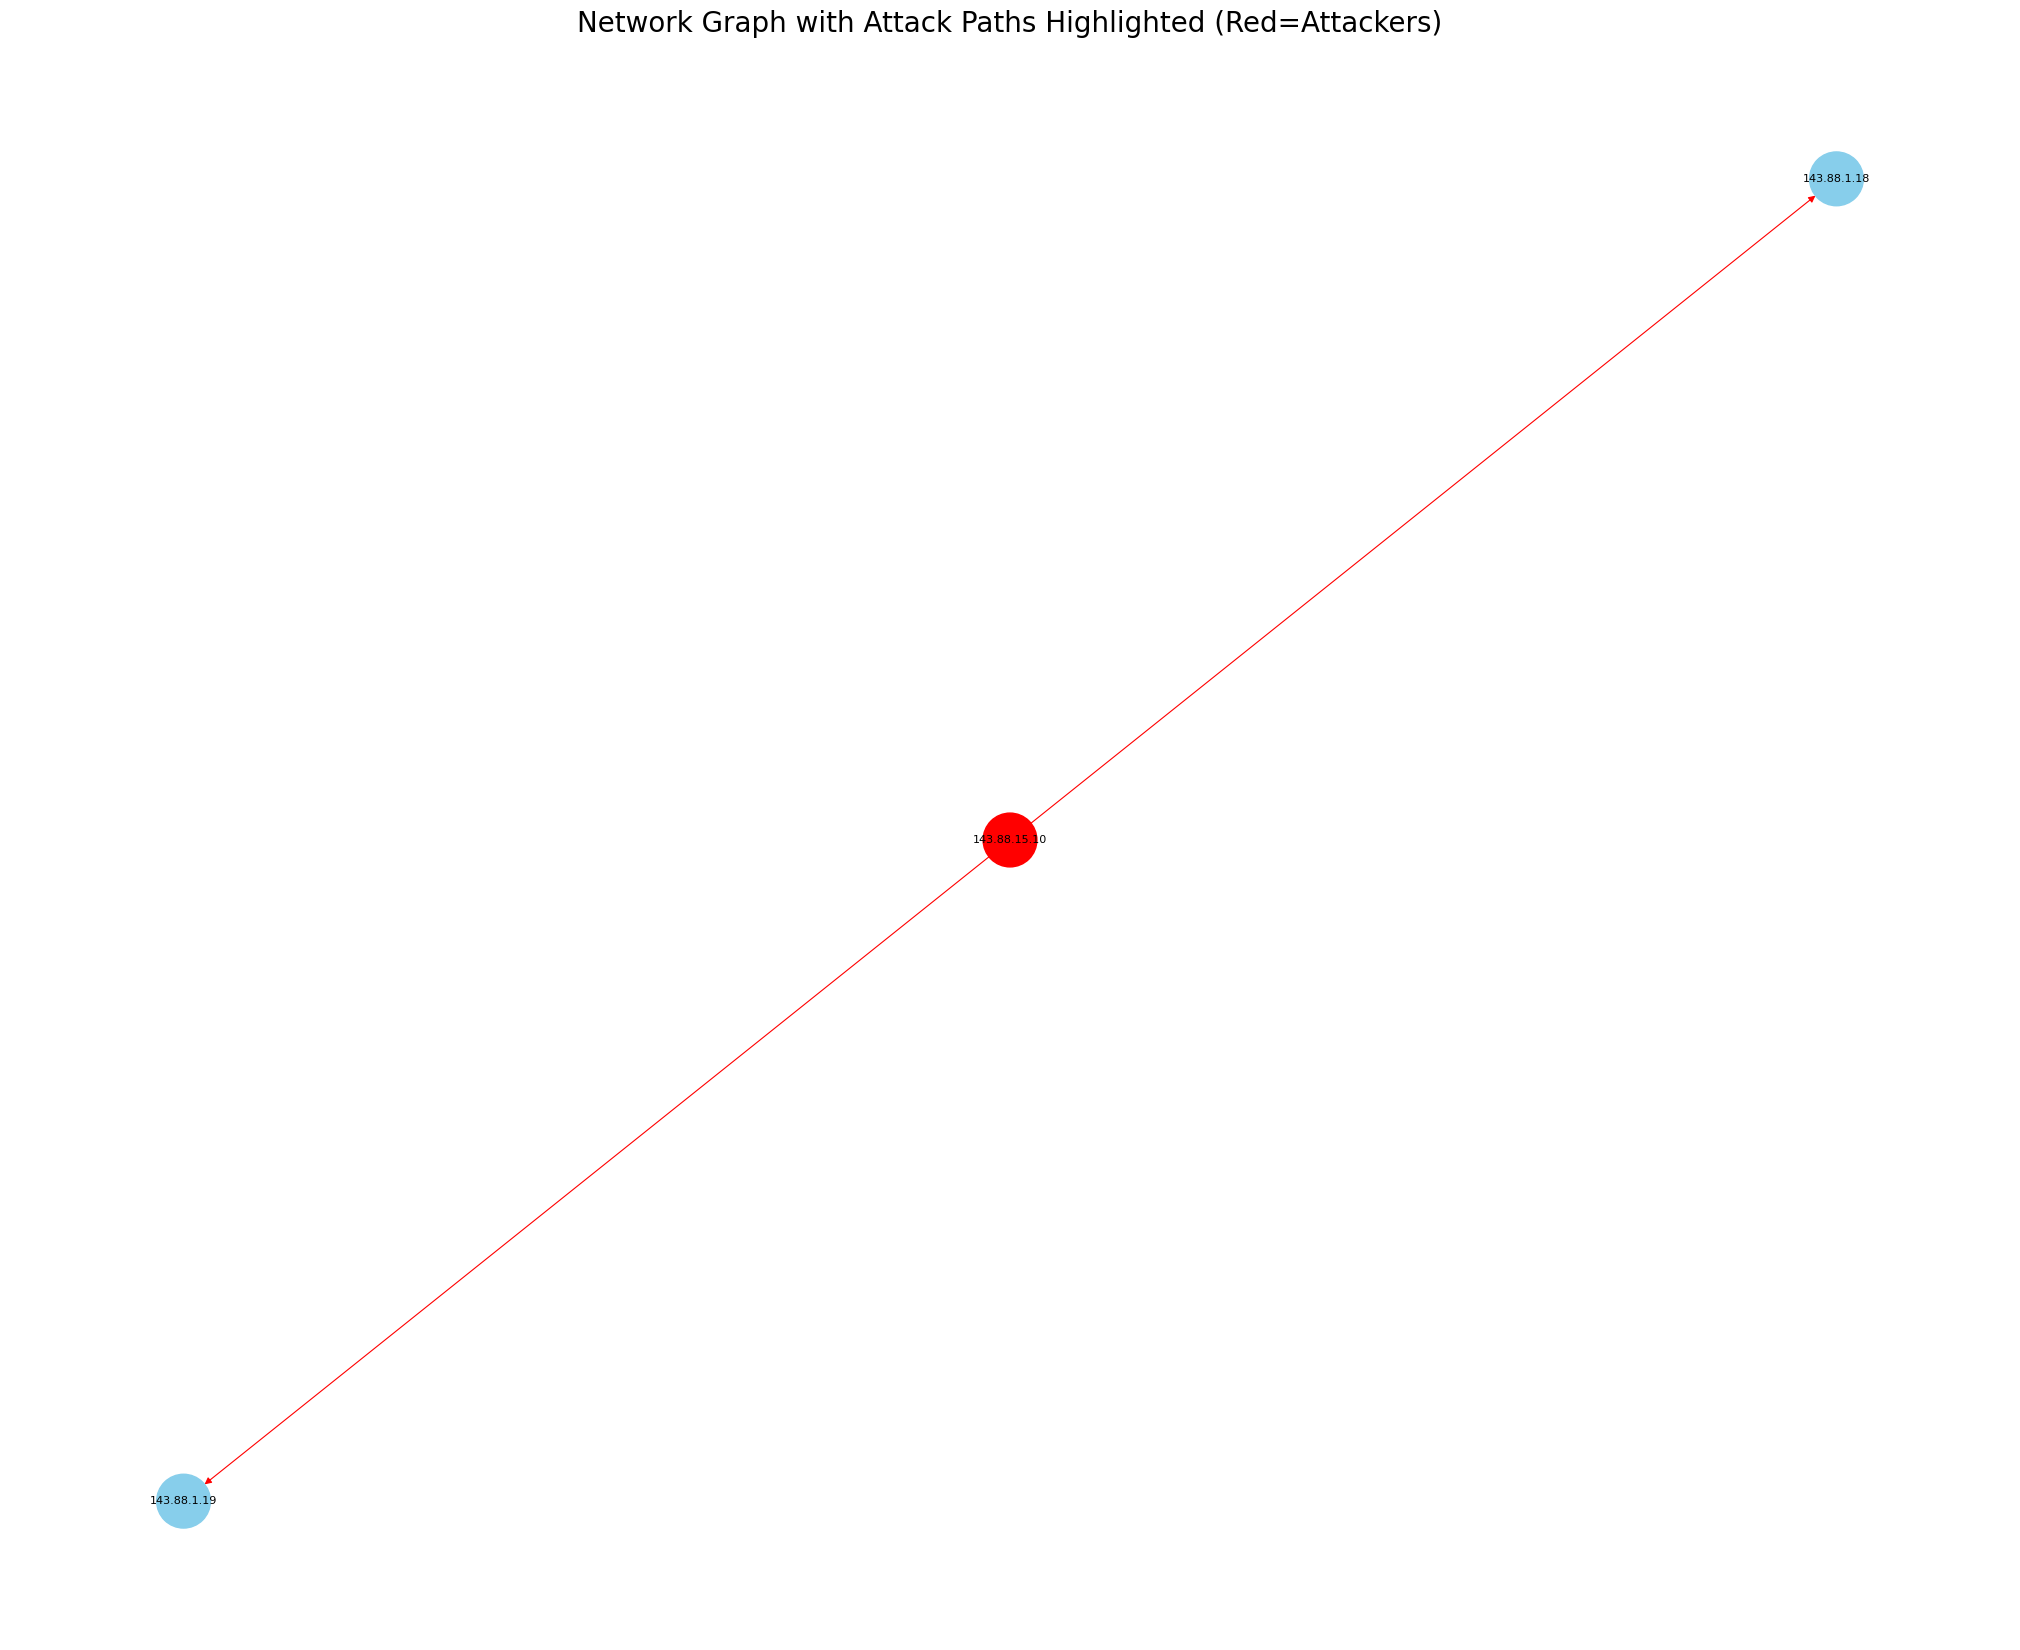

In [9]:
controller.ThesisAnalyzer.run_analysis()

In [10]:

JSON_OUTPUT_FILE = "structural_pivots.json"


controller.StructuralPivotAnalyzer.run_analysis(output_filepath=JSON_OUTPUT_FILE)

reporter = Controller.create_report_generator(filepath=JSON_OUTPUT_FILE)
reporter.generate_report()


STRUCTURAL PIVOT CANDIDATE ANALYSIS
--- Finding all A -> B -> C structural and temporal paths ---


[#CE10]  _: <CONNECTION> error: Failed to read from defunct connection IPv4Address(('localhost', 7687)) (ResolvedIPv6Address(('::1', 7687, 0, 0))): TimeoutError('timed out')
IOStream.flush timed out


Shared connection managed by controller; not closing driver here.


ServiceUnavailable: Failed to read from defunct connection IPv4Address(('localhost', 7687)) (ResolvedIPv6Address(('::1', 7687, 0, 0)))

In [ ]:
controller.KillChainAnalyzer.run_full_analysis()

In [ ]:
connection.status()

In [ ]:
connection.connect()